# Feature Selection

In [32]:
import pandas as pd
import numpy as np
from src.common.utils import get_root_directory, collate_array_elements
from src.common.stats import grangers_causality_test
from src.common.plotter import Plotter
import matplotlib.pyplot as plt
import numpy as np
from src.preprocessing.data_loader import DataLoader
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import mlflow
import mlflow.sklearn
import shap
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import f_regression, SelectKBest, mutual_info_regression, RFE,SequentialFeatureSelector
from sklearn.linear_model import Lasso

In [50]:
root_dir = get_root_directory()
plotter = Plotter(root_dir)
DL = DataLoader(root_dir)
DL.load_data()
# publishers = ['Cointelegraph', 'CoinDesk', 'CoinGape', 'Cointelegraph Deutschland', 'U.Today','The Block', 'Decrypt', 'Cointelegraph Brasil', 'Blockworks','br.cointelegraph.com']
DL.merge_selected_data(selected_data=['ETH','sentiment_analysis'])
DL.final_data.columns

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Index(['ETH_D_AvgPrc', 'ETH_D_PrcDir', 'ETH_YF_Op', 'ETH_YF_Hi', 'ETH_YF_Lo',
       'ETH_YF_Cls', 'ETH_YF_Vol', 'ETH_ES_AvgTransFee', 'ETH_ES_AvgGasPrc',
       'ETH_ES_BlkCnt', 'ETH_ES_BlkSz', 'ETH_ES_BlkTm', 'ETH_ES_ActAdd',
       'ETH_ES_DepCon', 'ETH_ES_GasLmt', 'ETH_ES_GasUsd', 'ETH_ES_VerCon',
       'ETH_OL_MktCap', 'ETH_OL_NewAdd', 'ETH_OL_ChnTrans', 'ETH_OL_ChnVol',
       'D_VADER_AvgScr_In', 'D_VADER_Sent_AvgIn', 'D_VADER_AvgScr_Ex',
       'D_VADER_Sent_AvgEx', 'D_FINBERT_AvgScr_In', 'D_FINBERT_Sent_AvgIn',
       'D_FINBERT_AvgScr_Ex', 'D_FINBERT_Sent_AvgEx', 'D_CRYPTOBERT_AvgScr_In',
       'D_CRYPTOBERT_Sent_AvgIn', 'D_CRYPTOBERT_AvgScr_Ex',
       'D_CRYPTOBERT_Sent_AvgEx'],
      dtype='object')

### Filter Methods

In [51]:
n_periods = 7
start_date = "01/01/2021"
end_date = "31/12/2023"

In [52]:
selected_features = ['ETH_D_PrcDir', 'D_VADER_Sent_AvgIn','D_FINBERT_Sent_AvgIn','D_CRYPTOBERT_Sent_AvgIn']
DL.select_features(features=selected_features)
DL.set_time_range(start_date=start_date, end_date=end_date)
train, test = DL.split_data(split_size=0.15)
# train, val = DL.split_data(split_type="train_val", split_size=0.15)

### Pearson

#### With All publishers

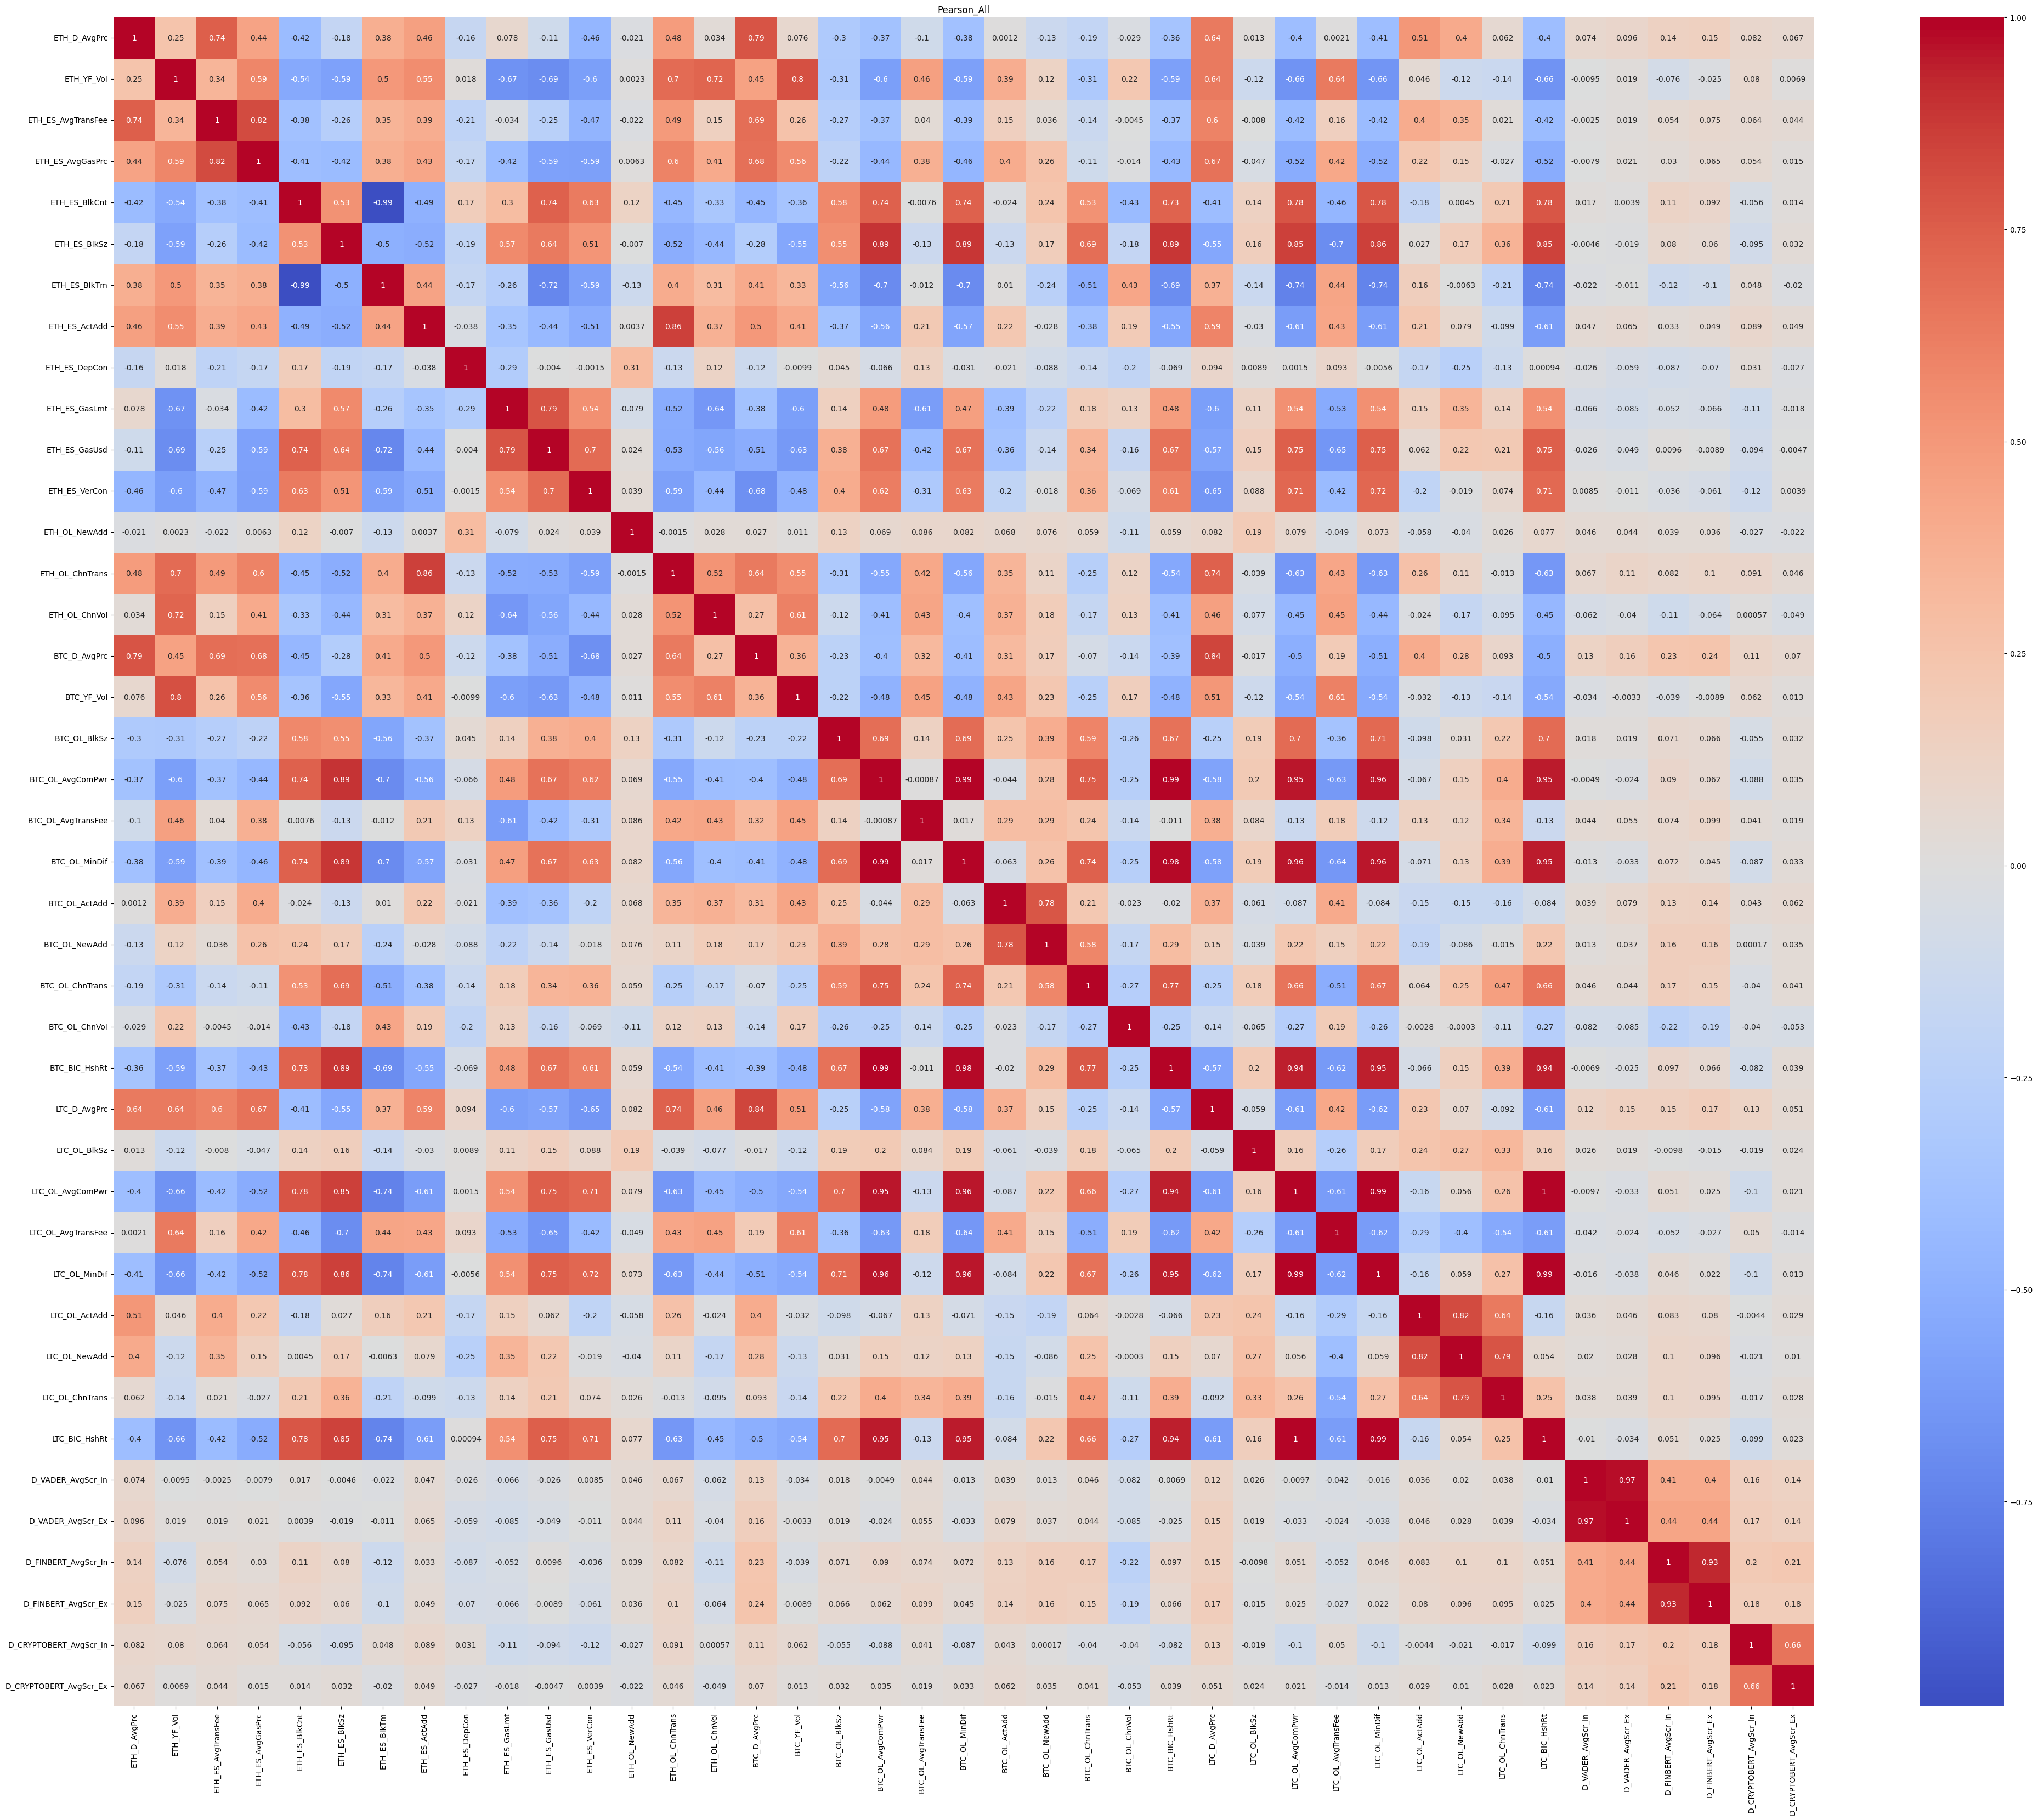

In [11]:
plotter.plot_correlation_matrix(DL.final_data, method="pearson", figsize=(50,40), title="Pearson_ALL")

In [12]:
plotter.save_graph(filepath=f"{root_dir}\\reports\\figures\\correlation_matrix")

#### With Selected publishers

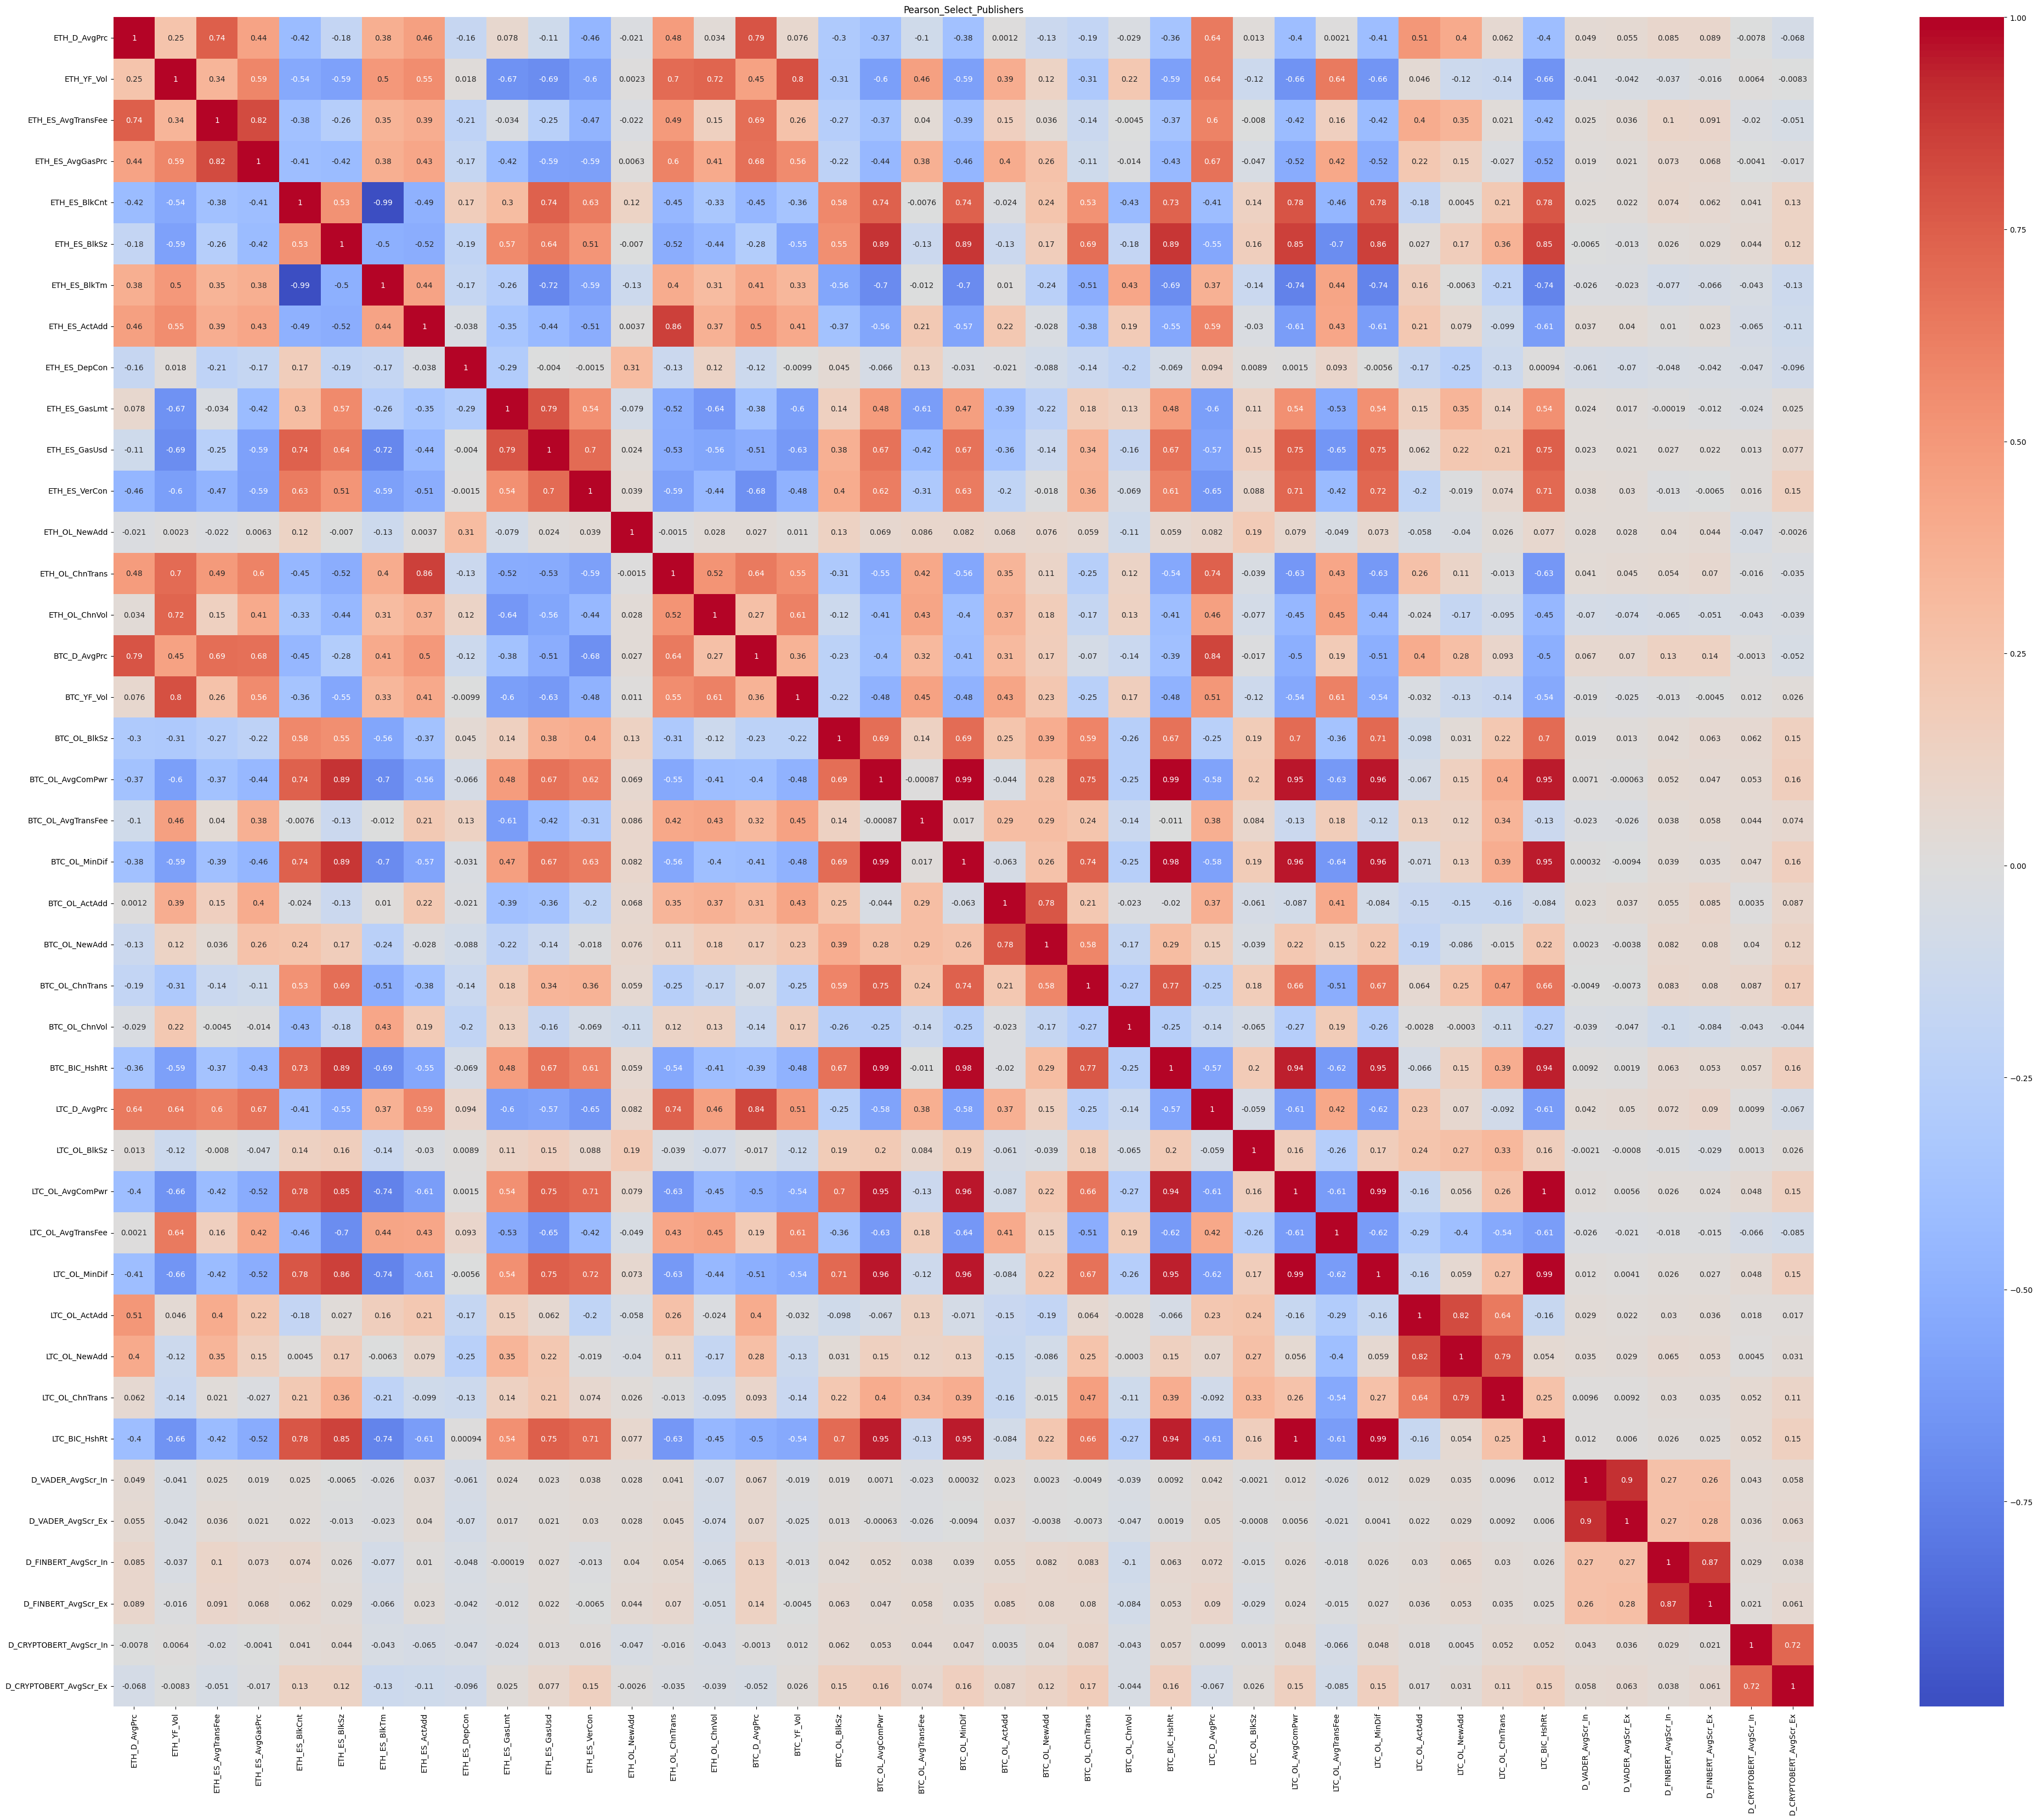

In [18]:
plotter.plot_correlation_matrix(DL.final_data, method="pearson", figsize=(50,40), title="Pearson_Select_Publishers")

In [19]:
plotter.save_graph(filepath=f"{root_dir}\\reports\\figures\\correlation_matrix")

### Spearman

#### With All publishers

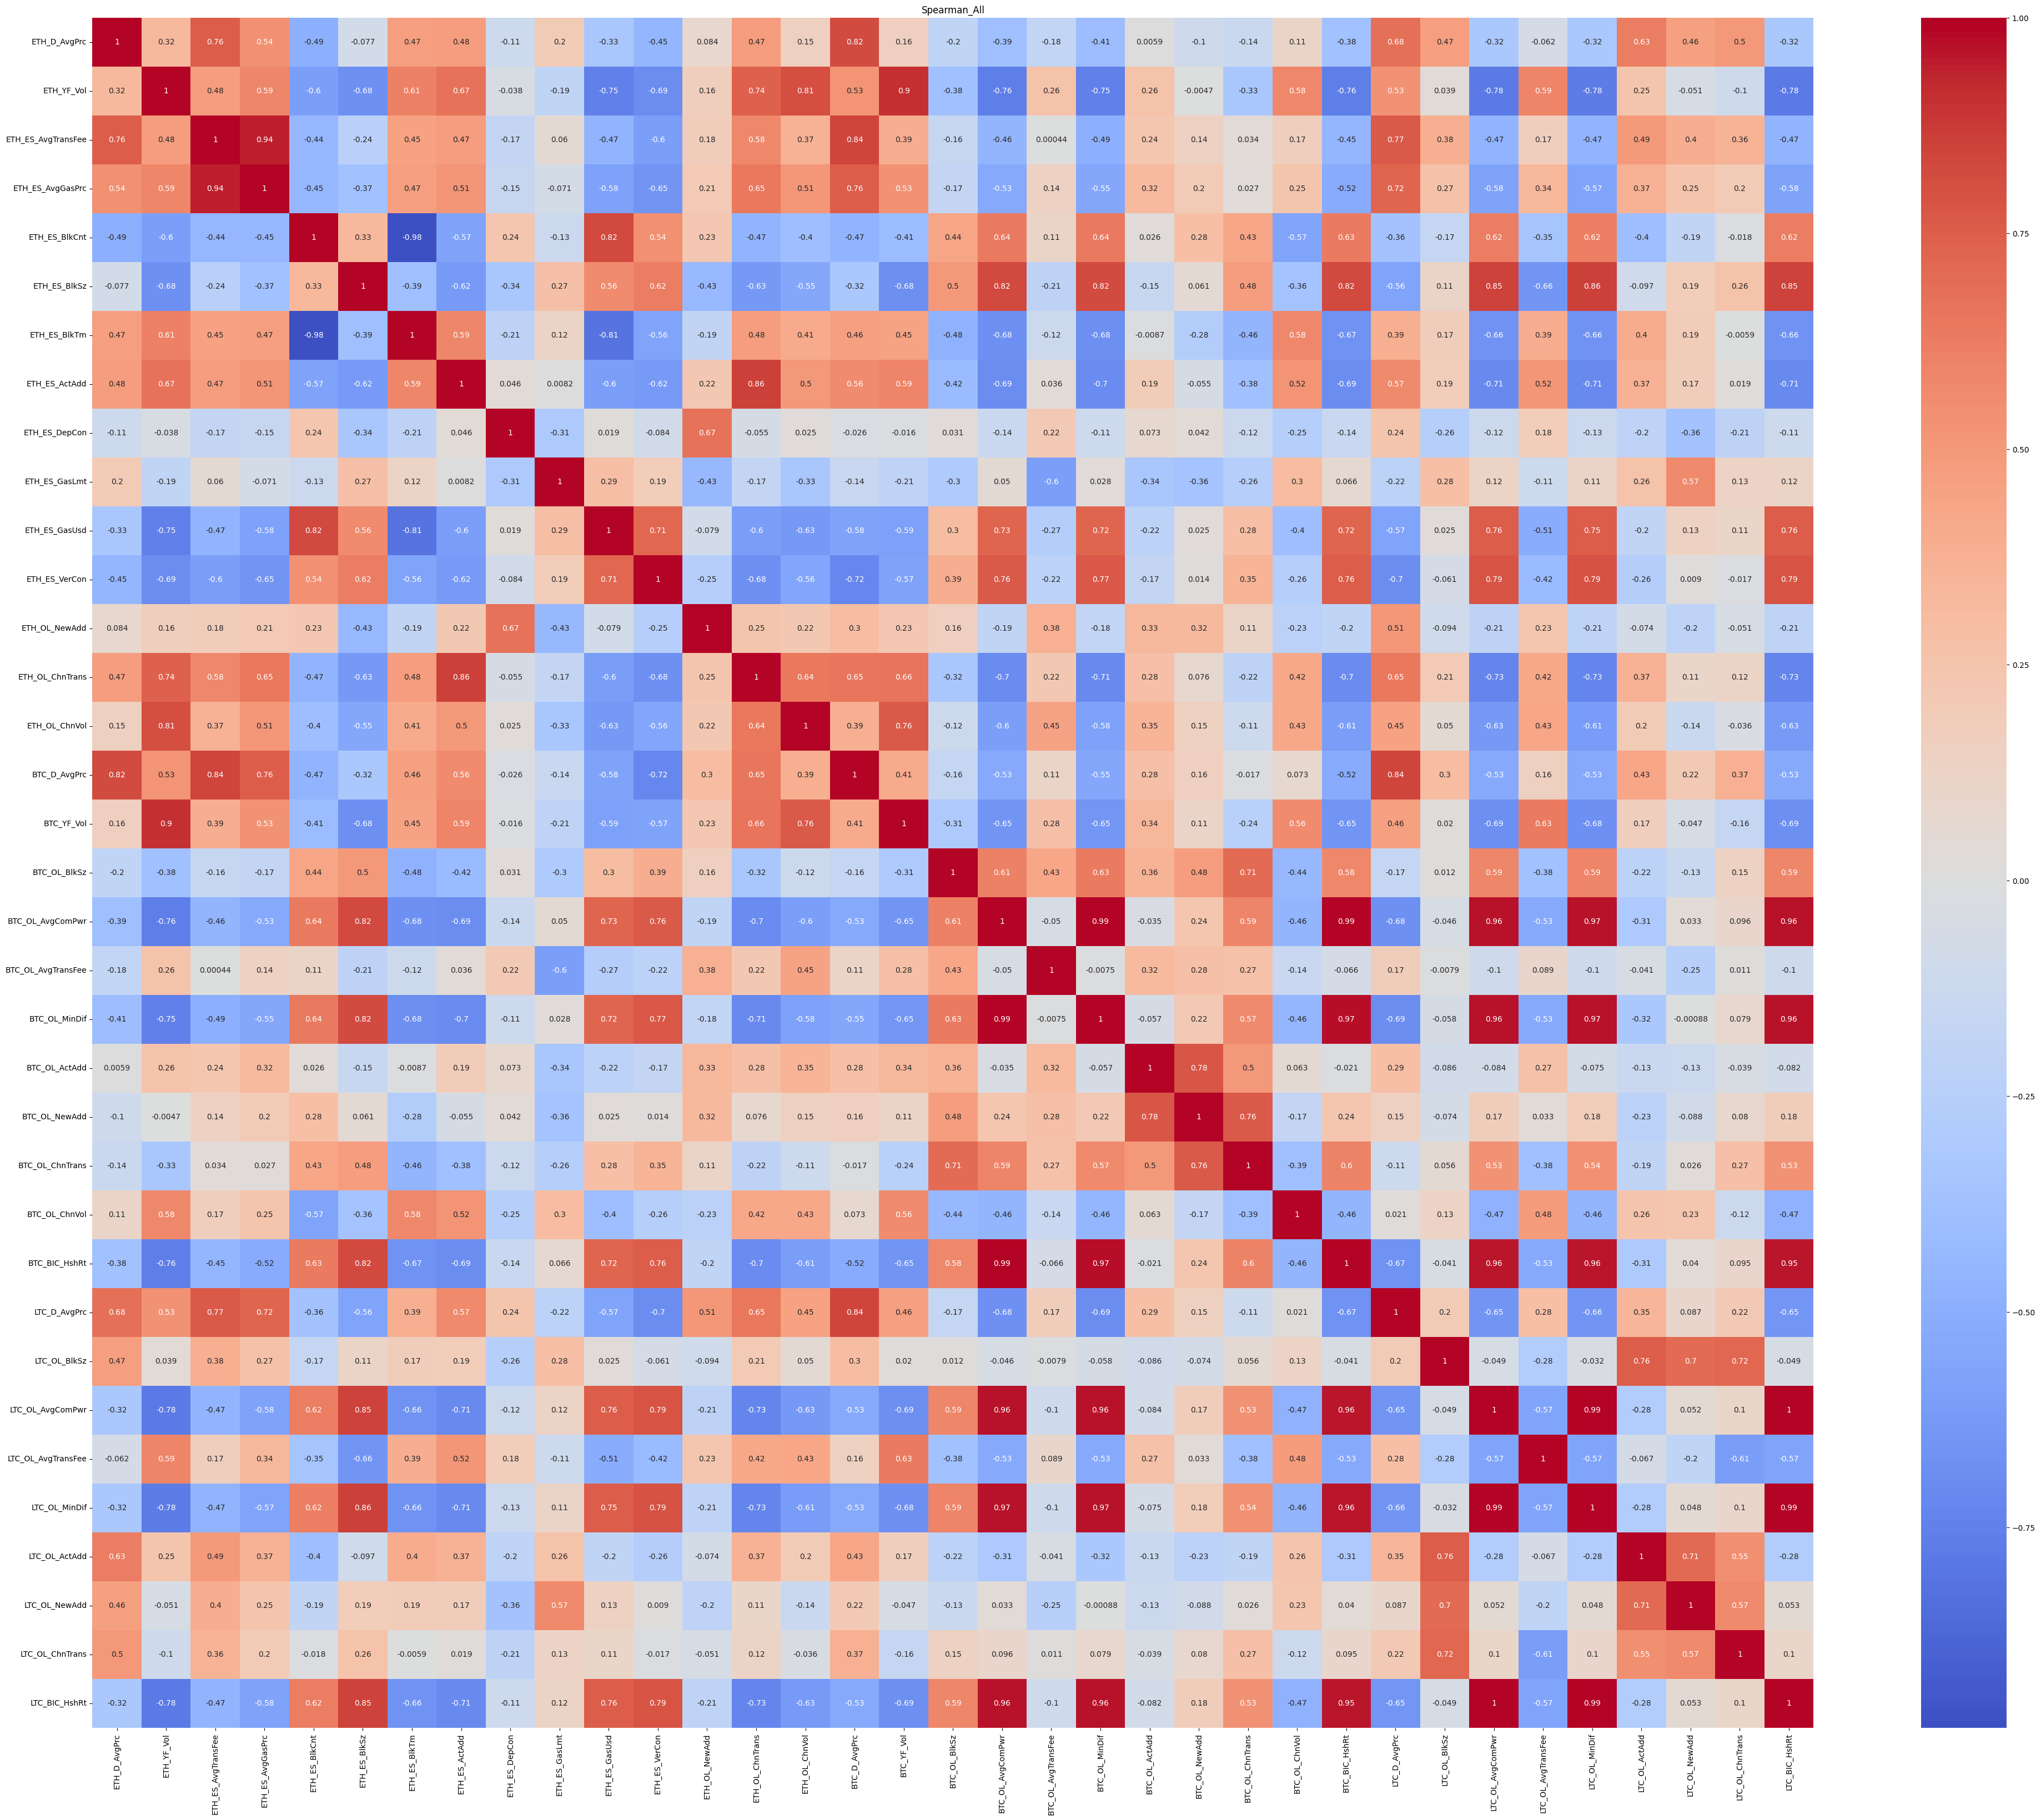

In [11]:
plotter.plot_correlation_matrix(DL.final_data, method="spearman", figsize=(50,40), title="Spearman_ALL")

In [12]:
plotter.save_graph(filepath=f"{root_dir}\\reports\\figures\\correlation_matrix")

In [54]:
correlations = {}
for column in train.columns:
    if column != "ETH_D_PrcDir":
        corr = train["ETH_D_PrcDir"].corr(train[column], method="spearman")
        correlations[column] = corr

corr_df = pd.DataFrame({
    'Column': list(correlations.keys()),
    'Coefficient': list(correlations.values())
})

corr_df['Absolute_Correlation'] = corr_df['Coefficient'].abs()
corr_df = corr_df.sort_values("Absolute_Correlation", ascending=False)

In [6]:
corr_list = corr_df['Column'].head(15).to_list()

In [55]:
corr_df.rename(columns={"Column":"Feature"}, inplace=True)
corr_df.set_index("Feature",inplace=True)

In [56]:
corr_df.sort_values(by="Feature", ascending=True)

,Coefficient,Absolute_Correlation
Feature,,
D_CRYPTOBERT_Sent_AvgIn,0.068861,0.068861
D_FINBERT_Sent_AvgIn,0.245116,0.245116
D_VADER_Sent_AvgIn,0.087198,0.087198


In [38]:
corr_df.sort_values(by="Feature", ascending=True)

,Coefficient,Absolute_Correlation
Feature,,
D_CRYPTOBERT_AvgScr_In,0.098645,0.098645
D_FINBERT_AvgScr_In,0.191568,0.191568
D_VADER_AvgScr_In,0.128878,0.128878


#### With Selected publishers

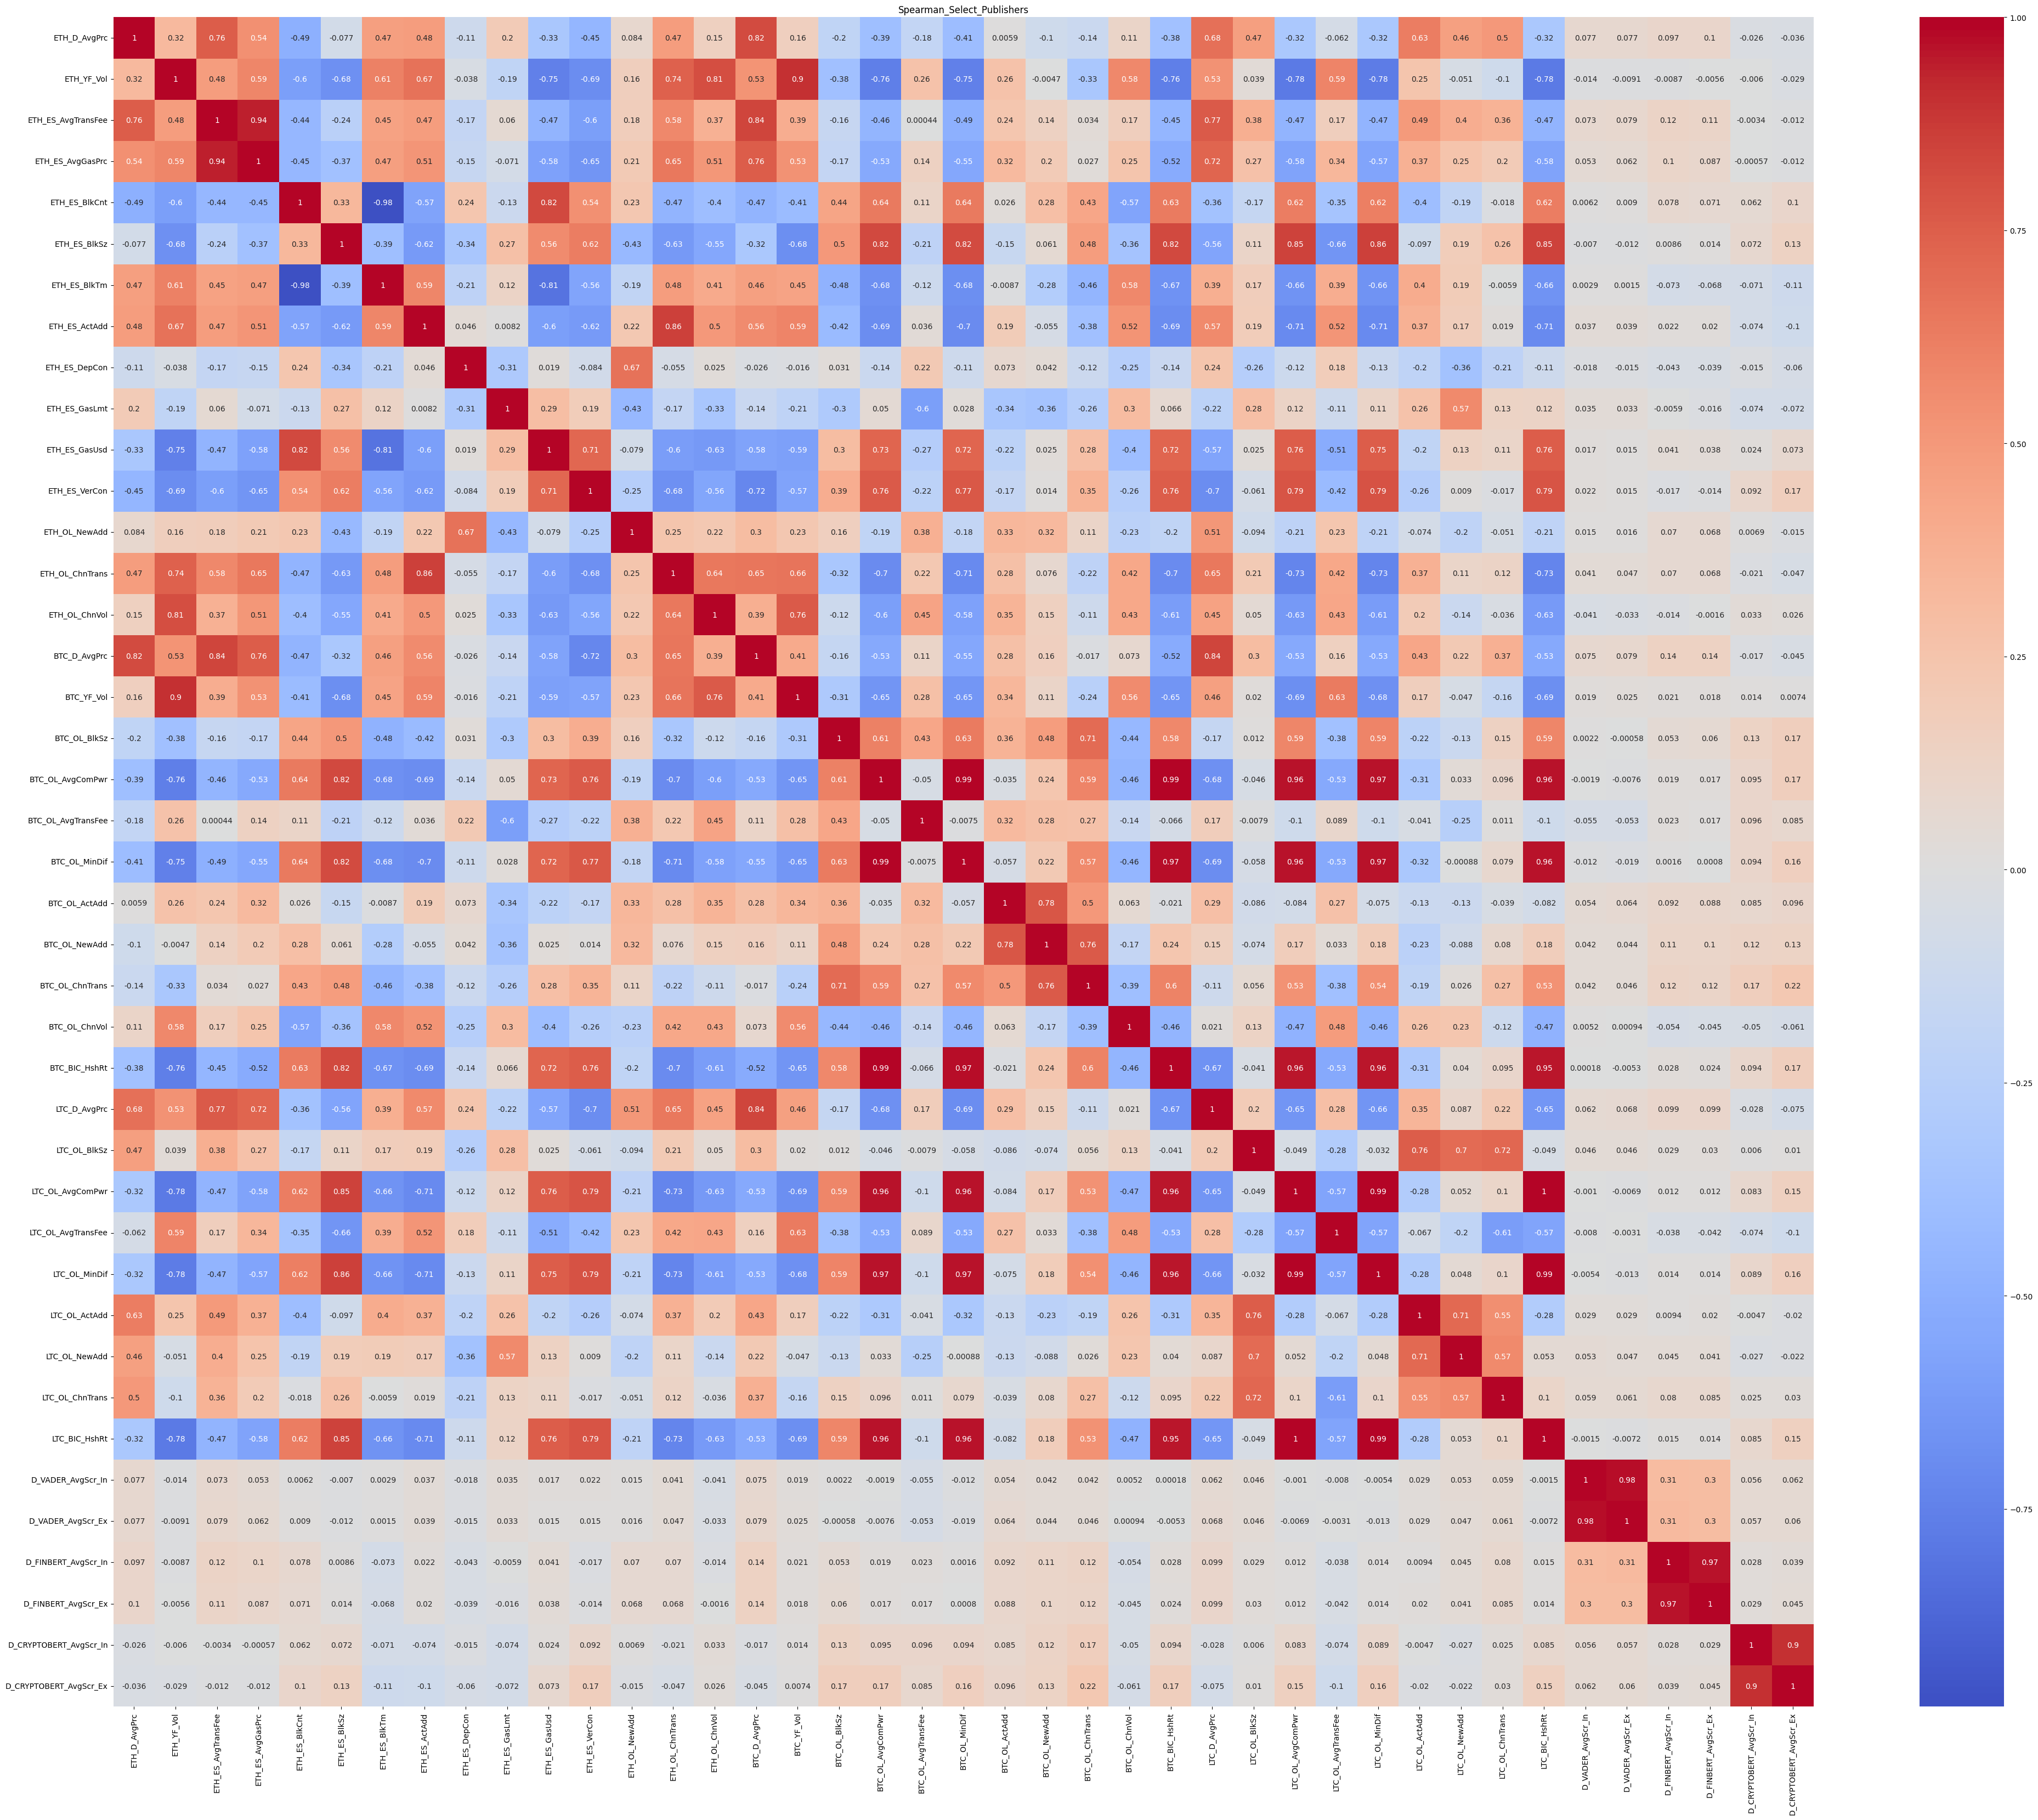

In [20]:
plotter.plot_correlation_matrix(DL.final_data, method="spearman", figsize=(50,40), title="Spearman_Select_Publishers")

In [21]:
plotter.save_graph(filepath=f"{root_dir}\\reports\\figures\\correlation_matrix")

### f_regression

In [8]:
train, test = DL.split_data(split_size=split_size)
features=[col for col in DL.final_data if col != 'ETH_D_AvgPrc']
targets=[col for col in DL.final_data if col == 'ETH_D_AvgPrc']
y_train, x_train = train[targets], train[features]

In [93]:
f_regression_selector = SelectKBest(score_func=f_regression, k=14)
f_regression = f_regression_selector.fit_transform(x_train, y_train)

C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [94]:
x_train.columns[f_regression_selector.get_support()]

Index(['ETH_ES_AvgTransFee', 'ETH_ES_AvgGasPrc', 'ETH_ES_ActAdd',
       'ETH_ES_VerCon', 'ETH_OL_ChnTrans', 'BTC_D_AvgPrc', 'BTC_OL_AvgComPwr',
       'BTC_OL_MinDif', 'BTC_BIC_HshRt', 'LTC_D_AvgPrc', 'LTC_OL_AvgComPwr',
       'LTC_OL_MinDif', 'LTC_OL_ActAdd', 'LTC_OL_NewAdd'],
      dtype='object')

### mutual_info_regression

In [57]:
features=[col for col in train if col != 'ETH_D_PrcDir']
print(features)
mi_scores = mutual_info_regression(train[features],pd.DataFrame(train["ETH_D_PrcDir"]))
mi_df = pd.DataFrame({'Feature': train[features].columns, 'MI Score': mi_scores})
mi_df.sort_values(by='MI Score', ascending=False)
mi_df.set_index("Feature",inplace=True)

['D_VADER_Sent_AvgIn', 'D_FINBERT_Sent_AvgIn', 'D_CRYPTOBERT_Sent_AvgIn']


C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [58]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
mi_df["MinMax"] = scaler.fit_transform(pd.DataFrame(mi_df["MI Score"]))

In [59]:
mi_df

,MI Score,MinMax
Feature,,
D_VADER_Sent_AvgIn,0.000000,0.000000
D_FINBERT_Sent_AvgIn,0.040025,1.000000
D_CRYPTOBERT_Sent_AvgIn,0.020288,0.506888


In [41]:
mi_df

,MI Score,MinMax
Feature,,
D_VADER_AvgScr_In,0.000000,0.000000
D_FINBERT_AvgScr_In,0.010012,0.431475
D_CRYPTOBERT_AvgScr_In,0.023203,1.000000


In [26]:
mi_df

,MI Score,MinMax
Feature,,
ETH_YF_Vol,0.250335,0.104596
ETH_ES_AvgTransFee,0.708206,0.379510
ETH_ES_AvgGasPrc,0.439608,0.218239
ETH_ES_BlkCnt,0.630077,0.332600
ETH_ES_BlkSz,0.732499,0.394096
ETH_ES_BlkTm,0.585931,0.306094
ETH_ES_ActAdd,0.331088,0.153081
ETH_ES_DepCon,0.231490,0.093281
ETH_ES_GasLmt,0.369110,0.175910


In [12]:
mi_selected_features = mi_df.sort_values(by='MI Score', ascending=False).head(10).index.tolist()
mi_selected_features

['BTC_D_AvgPrc',
 'BTC_OL_MinDif',
 'LTC_D_AvgPrc',
 'LTC_OL_MinDif',
 'ETH_ES_GasUsd',
 'LTC_BIC_HshRt',
 'ETH_ES_BlkSz',
 'ETH_ES_AvgTransFee',
 'BTC_BIC_HshRt',
 'ETH_ES_BlkCnt']

## Grangers Causality test

In [40]:
from src.common.stats import grangers_causality_test

In [60]:
from statsmodels.tsa.stattools import adfuller
def make_stationary(df, significance=0.05, max_diffs=5):
    """
    Iterates through each column in a DataFrame and differences it until it becomes stationary
    based on the Augmented Dickey-Fuller (ADF) test.
    
    Parameters:
    - df: Pandas DataFrame with time series data.
    - significance: Significance level for the ADF test (default 0.05).
    - max_diffs: Maximum number of differences to apply (default 5).
    
    Returns:
    - A new DataFrame with differenced values.
    - A dictionary mapping column names to the number of differences applied.
    """
    stationary_df = df.copy()
    diff_counts = {}  # Store number of differences applied per column
    
    for col in df.columns:
        series = df[col].dropna()  # Drop NaNs before testing
        diff_count = 0
        
        # Perform differencing until stationary or max_diffs reached
        while diff_count < max_diffs:
            adf_test = adfuller(series)
            p_value = adf_test[1]
            
            if p_value < significance:
                break  # Stop if stationary
            
            series = series.diff().dropna()  # Apply differencing
            diff_count += 1
        
        stationary_df[col] = series  # Store transformed series
        diff_counts[col] = diff_count
    
    return stationary_df.dropna() , diff_counts

In [61]:
stationary_df, diff_counts = make_stationary(train)

In [62]:
result = grangers_causality_test(stationary_df,"ETH_D_PrcDir", max_lag=30)

In [63]:
diff_counts

{'ETH_D_PrcDir': 0,
 'D_VADER_Sent_AvgIn': 0,
 'D_FINBERT_Sent_AvgIn': 0,
 'D_CRYPTOBERT_Sent_AvgIn': 0}

In [64]:
df_result = pd.DataFrame.from_dict(result, orient='index')

# Optional: reset index to turn the keys into a column
df_result.reset_index(inplace=True)
df_result.columns = ['Feature', 'Causal', 'Significant_Lags']

df_result["Num_Significant_Lags"] = df_result["Significant_Lags"].apply(len)
df_result.sort_values("Num_Significant_Lags", ascending=False)
df_result.set_index("Feature",inplace=True)

In [65]:
df_result

,Causal,Significant_Lags,Num_Significant_Lags
Feature,,,
D_VADER_Sent_AvgIn,True,"[6, 7, 9]",3
D_FINBERT_Sent_AvgIn,True,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",30
D_CRYPTOBERT_Sent_AvgIn,False,[],0


In [45]:
df_result

,Causal,Significant_Lags,Num_Significant_Lags
Feature,,,
D_VADER_AvgScr_In,True,[2],1
D_FINBERT_AvgScr_In,True,[4],1
D_CRYPTOBERT_AvgScr_In,False,[],0


In [22]:
df_result

,Causal,Significant_Lags,Num_Significant_Lags
Feature,,,
ETH_YF_Vol,True,"[3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16,...",27
ETH_ES_AvgTransFee,True,"[11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 2...",20
ETH_ES_AvgGasPrc,True,"[11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 2...",20
ETH_ES_BlkCnt,False,[],0
ETH_ES_BlkSz,False,[],0
ETH_ES_BlkTm,False,[],0
ETH_ES_ActAdd,False,[],0
ETH_ES_DepCon,True,"[29, 30]",2
ETH_ES_GasLmt,True,[26],1


In [18]:
list_gc = df_result[df_result['Num_Significant_Lags']>0].index.tolist()

In [19]:
corr_list = corr_df[corr_df['Absolute_Correlation']>=0.3].index.to_list()
set1, set2, set3 = set(corr_list), set(mi_selected_features), set(list_gc)

# Get union of all unique values
all_values = sorted(set1 | set2 | set3)

# Create DataFrame
df = pd.DataFrame({
    'Feature': all_values,
    'Spearman': [1 if val in set1 else 0 for val in all_values],
    'Mutual Information': [1 if val in set2 else 0 for val in all_values],
    'Grangers Causality': [1 if val in set3 else 0 for val in all_values],
})

df['Total'] = df[['Spearman', 'Mutual Information', 'Grangers Causality']].sum(axis=1)
df['NewCol'] = (((df['Grangers Causality'] == 1) & (df['Spearman'] == 1)) | ((df['Grangers Causality'] == 1) & (df['Mutual Information'] == 1)) | (df['Grangers Causality'] == 1)).astype(int)
df.sort_values('Total', ascending=False)
df.set_index("Feature",inplace=True)

In [20]:
df.sort_values('Total', ascending=False)

,Spearman,Mutual Information,Grangers Causality,Total,NewCol
Feature,,,,,
LTC_D_AvgPrc,1,1,1,3,1
BTC_OL_MinDif,1,1,1,3,1
BTC_D_AvgPrc,1,1,1,3,1
ETH_ES_AvgTransFee,1,1,1,3,1
BTC_BIC_HshRt,1,1,0,2,0
ETH_ES_BlkCnt,1,1,0,2,0
LTC_OL_MinDif,1,1,0,2,0
LTC_BIC_HshRt,1,1,0,2,0
ETH_ES_GasUsd,0,1,1,2,1


In [129]:
print(len(df[df['Total']>1]))

11


In [130]:
len(corr_df)

33

### RFE

In [23]:
model = XGBRegressor(random_state=42)
rfe = RFE(estimator=model, n_features_to_select=14)
rfe.fit(x_train, y_train)
xgb_selected_features = x_train.columns[rfe.support_]
ranking = pd.DataFrame({'Feature': x_train.columns, 'Rank': rfe.ranking_})
print("Top selected features:", xgb_selected_features.tolist())
print(ranking.sort_values(by="Rank"))

Top selected features: ['ETH_ES_AvgTransFee', 'ETH_ES_BlkSz', 'ETH_ES_GasLmt', 'ETH_ES_GasUsd', 'ETH_OL_NewAdd', 'BTC_D_AvgPrc', 'BTC_OL_AvgComPwr', 'BTC_OL_AvgTransFee', 'BTC_OL_MinDif', 'BTC_OL_ActAdd', 'LTC_D_AvgPrc', 'LTC_OL_AvgComPwr', 'LTC_OL_MinDif', 'LTC_BIC_HshRt']
                   Feature  Rank
19           BTC_OL_MinDif     1
25            LTC_D_AvgPrc     1
29           LTC_OL_MinDif     1
20           BTC_OL_ActAdd     1
18      BTC_OL_AvgTransFee     1
17        BTC_OL_AvgComPwr     1
27        LTC_OL_AvgComPwr     1
11           ETH_OL_NewAdd     1
33           LTC_BIC_HshRt     1
14            BTC_D_AvgPrc     1
8            ETH_ES_GasLmt     1
1       ETH_ES_AvgTransFee     1
4             ETH_ES_BlkSz     1
9            ETH_ES_GasUsd     1
5             ETH_ES_BlkTm     2
26            LTC_OL_BlkSz     3
23           BTC_OL_ChnVol     4
36     D_FINBERT_AvgScr_In     5
34       D_VADER_AvgScr_In     6
15              BTC_YF_Vol     7
31           LTC_OL_NewAdd     8

In [27]:
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()
x_train_scaled = pd.DataFrame(x_scaler.fit_transform(x_train), columns=x_train.columns, index=x_train.index)
y_train_scaled= pd.DataFrame(y_scaler.fit_transform(y_train), columns=y_train.columns, index=y_train.index)
model = Lasso(random_state=42, max_iter=100000)
rfe = RFE(estimator=model, n_features_to_select=14)
rfe.fit(x_train_scaled, y_train_scaled)
lasso_selected_features = x_train_scaled.columns[rfe.support_]
ranking = pd.DataFrame({'Feature': x_train_scaled.columns, 'Rank': rfe.ranking_})
print("Top selected features:", lasso_selected_features.tolist())
print(ranking.sort_values(by="Rank"))

Top selected features: ['LTC_OL_BlkSz', 'LTC_OL_AvgComPwr', 'LTC_OL_AvgTransFee', 'LTC_OL_MinDif', 'LTC_OL_ActAdd', 'LTC_OL_NewAdd', 'LTC_OL_ChnTrans', 'LTC_BIC_HshRt', 'D_VADER_AvgScr_In', 'D_VADER_AvgScr_Ex', 'D_FINBERT_AvgScr_In', 'D_FINBERT_AvgScr_Ex', 'D_CRYPTOBERT_AvgScr_In', 'D_CRYPTOBERT_AvgScr_Ex']
                   Feature  Rank
39  D_CRYPTOBERT_AvgScr_Ex     1
26            LTC_OL_BlkSz     1
27        LTC_OL_AvgComPwr     1
28      LTC_OL_AvgTransFee     1
30           LTC_OL_ActAdd     1
31           LTC_OL_NewAdd     1
29           LTC_OL_MinDif     1
33           LTC_BIC_HshRt     1
34       D_VADER_AvgScr_In     1
35       D_VADER_AvgScr_Ex     1
36     D_FINBERT_AvgScr_In     1
37     D_FINBERT_AvgScr_Ex     1
32         LTC_OL_ChnTrans     1
38  D_CRYPTOBERT_AvgScr_In     1
25            LTC_D_AvgPrc     2
24           BTC_BIC_HshRt     3
23           BTC_OL_ChnVol     4
22         BTC_OL_ChnTrans     5
21           BTC_OL_NewAdd     6
20           BTC_OL_ActAdd     

In [33]:
inner_join = list(set(xgb_selected_features.tolist()) & set(mi_selected_features))
print(f"Total {len(inner_join)} features are selected: {inner_join}")

Total 10 features are selected: ['BTC_D_AvgPrc', 'BTC_OL_MinDif', 'LTC_OL_AvgComPwr', 'ETH_ES_GasUsd', 'ETH_ES_BlkSz', 'LTC_D_AvgPrc', 'LTC_BIC_HshRt', 'ETH_ES_AvgTransFee', 'LTC_OL_MinDif', 'BTC_OL_AvgComPwr']


#### Forward addition

In [84]:
model = XGBRegressor(random_state=42)
SFS_forward = SequentialFeatureSelector(estimator=model, n_features_to_select=9)
SFS_forward.fit(x_train, y_train)
selected_features = x_train.columns[SFS_forward.support_]
print("Top selected features:", selected_features.tolist())

Top selected features: ['ETH_YF_Vol', 'ETH_ES_AvgTransFee', 'ETH_ES_AvgGasPrc', 'ETH_ES_BlkTm', 'ETH_ES_GasUsd', 'BTC_D_AvgPrc', 'LTC_OL_ActAdd', 'LTC_OL_NewAdd', 'D_CRYPTOBERT_AvgScr_Ex']


#### Backward Elimination

In [85]:
model = XGBRegressor(random_state=42)
SFS_backward = SequentialFeatureSelector(estimator=model, n_features_to_select=9, direction="backward")
SFS_backward.fit(x_train, y_train)
selected_features = x_train.columns[SFS_backward.support_]
print("Top selected features:", selected_features.tolist())

KeyboardInterrupt: 

### Embedded

In [100]:
model = XGBRegressor(random_state=42)
model.fit(x_train,y_train)
importance_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print(importance_df)

                   Feature  Importance
14            BTC_D_AvgPrc    0.510458
9            ETH_ES_GasUsd    0.382038
19           BTC_OL_MinDif    0.022893
4             ETH_ES_BlkSz    0.021564
8            ETH_ES_GasLmt    0.013310
1       ETH_ES_AvgTransFee    0.012686
18      BTC_OL_AvgTransFee    0.008543
27        LTC_OL_AvgComPwr    0.006344
29           LTC_OL_MinDif    0.004607
25            LTC_D_AvgPrc    0.003878
17        BTC_OL_AvgComPwr    0.002883
11           ETH_OL_NewAdd    0.002137
20           BTC_OL_ActAdd    0.001060
33           LTC_BIC_HshRt    0.001037
31           LTC_OL_NewAdd    0.000631
26            LTC_OL_BlkSz    0.000620
36     D_FINBERT_AvgScr_In    0.000615
13           ETH_OL_ChnVol    0.000427
28      LTC_OL_AvgTransFee    0.000354
3            ETH_ES_BlkCnt    0.000343
32         LTC_OL_ChnTrans    0.000316
23           BTC_OL_ChnVol    0.000293
37     D_FINBERT_AvgScr_Ex    0.000282
34       D_VADER_AvgScr_In    0.000268
30           LTC_OL_ActAd